# YOLO 객체 탐지

## 객체 탐지는 무엇을 해결하는가

앞에서 학습한 이미지 분류 모델은 사진 전체를 보고 `버스`처럼 **대표 클래스 하나**를 예측한다.
하지만 버스 사진 안에는 버스뿐 아니라 여러 사람도 있고, 후속 프로그램은 각 객체가 어디에 있는지도 알아야 한다.

객체 탐지(Object Detection)는 이미지 속 객체마다 다음 세 가지를 출력하는 문제이다.

- **클래스(class)**: 무엇인가? 예: `person`, `bus`
- **바운딩 박스(bounding box)**: 어디에 있는가? 객체를 둘러싼 사각형 좌표
- **confidence**: 이 탐지 결과를 모델이 얼마나 확신하는가? 0~1 범위의 점수

예를 들어 버스와 사람 4명이 있는 사진이라면 분류 모델은 `bus` 하나만 출력할 수 있지만, 객체 탐지 모델은 **버스 박스 1개와 사람 박스 4개**를 각각 출력할 수 있다.

## YOLO는 무엇인가

YOLO(You Only Look Once)는 입력 이미지를 한 번의 신경망 순전파로 처리하여 여러 객체의 **종류와 위치를 함께 예측**하는 객체 탐지 모델 계열이다.
여기서 "한 번 본다"는 객체마다 이미지를 따로 잘라 반복 처리한다는 뜻이 아니라, 이미지 전체를 한 번에 넣어 많은 후보 박스를 동시에 계산한다는 뜻이다.

이 수업에서는 복잡한 내부 수식보다 **YOLO가 후보 박스를 만드는 흐름, 바운딩 박스, confidence, IoU, NMS, 사전학습 모델 사용법과 결과 해석**을 중심으로 학습한다.

## 학습 목표

1. 이미지 분류와 객체 탐지의 차이를 설명할 수 있다.
2. YOLO가 이미지 특징으로 객체의 종류와 위치를 예측하는 흐름을 설명할 수 있다.
3. 바운딩 박스, confidence, IoU, NMS의 역할을 구분할 수 있다.
4. YOLO11 사전학습 모델의 탐지 결과에서 좌표, 클래스, confidence를 읽을 수 있다.
5. 커스텀 데이터 학습 흐름과 주요 평가 지표를 설명할 수 있다.

## 1. YOLO는 객체를 어떻게 구분하는가

YOLO도 앞에서 배운 CNN을 사용한다. 다만 이미지 전체를 클래스 하나로 분류하고 끝내지 않고, CNN이 만든 특징을 이용해 **여러 위치의 객체 후보와 각 후보의 종류**를 동시에 예측한다.

### 1단계: 이미지를 숫자로 입력한다

컬러 이미지 한 장은 Red, Green, Blue 픽셀값을 가진 `(채널, 높이, 너비)`, 즉 `(C, H, W)` 형태의 Tensor로 변환된다.
실제 모델은 여러 이미지를 한꺼번에 처리하므로 맨 앞에 배치 크기 `B`가 추가된 `(B, C, H, W)` 형태로 입력받는다.

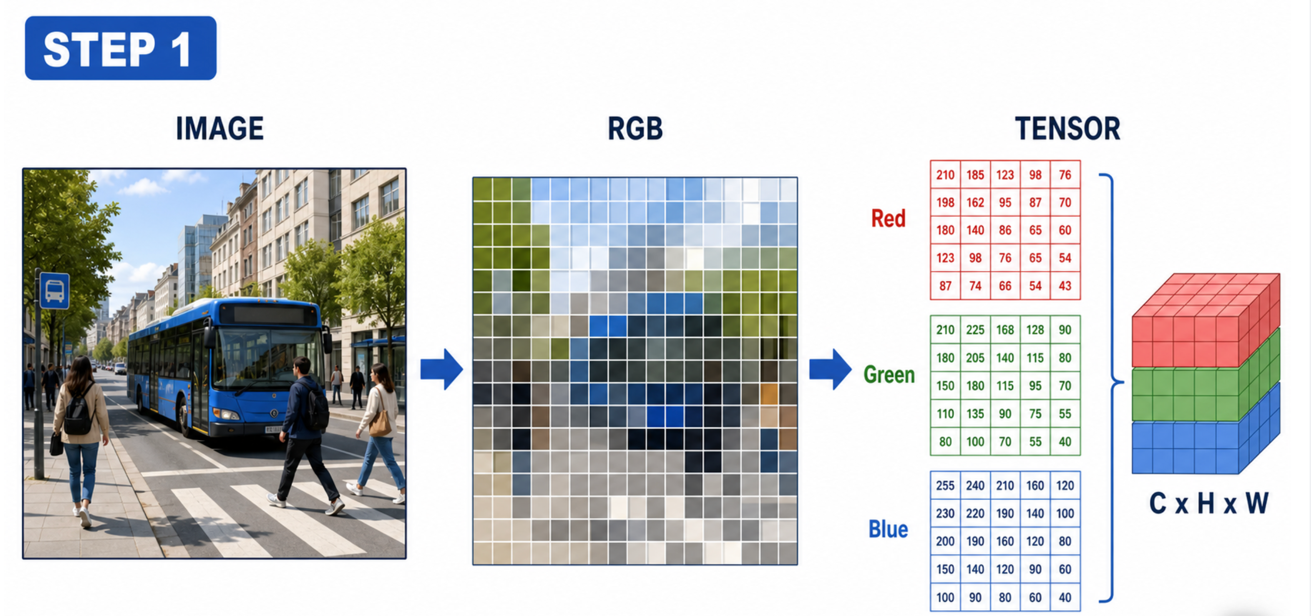

*그림은 이미지 한 장이 RGB 채널의 숫자 배열을 거쳐 `(C, H, W)` Tensor가 된다. YOLO에 들어갈 때는 여러 장을 묶어 `(B, C, H, W)`가 된다.*


### 2단계: CNN이 특징을 추출한다

합성곱 계층은 처음에는 선, 모서리, 색 변화, 질감처럼 작은 특징에 반응한다.
층이 깊어지면 앞에서 찾은 단순한 특징을 조합하여 곡선, 반복 무늬, 바퀴나 창문 일부처럼 더 복잡한 부분 패턴에 반응한다.

이 반응 결과가 **feature map**이다. feature map은 사진 자체가 아니라, 이미지의 어느 위치에서 특정 특징이 강하게 나타났는지를 숫자로 기록한 배열이다.

중요한 점은 **feature map 하나가 곧 `사람`이나 `버스`를 뜻하지 않는다는 것**이다.
YOLO에 사람 전용 커널 하나, 버스 전용 커널 하나가 따로 있는 것이 아니라 여러 feature map의 선·질감·부분 패턴 반응을 함께 조합하여 객체를 구분한다.

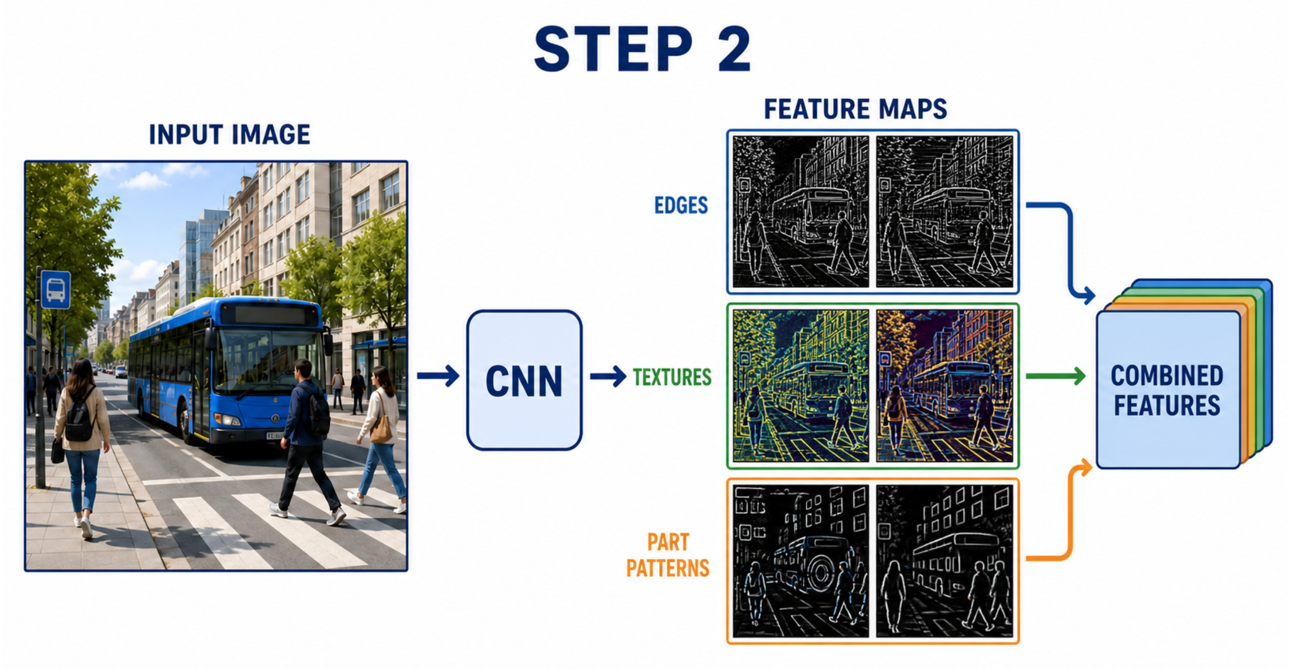

*1단계와 같은 버스 이미지를 CNN에 넣은 뒤, 같은 장면의 선·질감·부분 패턴에 강하게 반응한 feature map을 함께 사용하는 흐름이다. 그림의 색과 강조선은 feature map 반응을 이해하기 쉽게 표현한 것이며, 실제 값은 숫자 배열이다.*


***Combined Features**는 특징을 한 장의 완성된 그림으로 합쳤다는 뜻이 아니다.
CNN의 여러 계층에서 만들어진 많은 feature map을 다음 단계가 사용할 수 있도록 모아 놓은 **숫자 배열 묶음**이다.*


### 3단계: Combined Features를 여러 크기로 정리한다

얕은 계층의 feature map은 위치 정보가 자세하지만 아직 단순한 선과 질감 중심이고, 깊은 계층의 feature map은 객체를 구분하기 좋은 복잡한 특징을 가지지만 공간 크기가 작다.
YOLO의 **Neck**은 이 서로 다른 장점을 함께 사용하도록 feature map의 크기를 맞추고 연결한다.

- **High Resolution**: 칸이 촘촘하여 멀리 있는 작은 사람이나 객체 경계를 정확히 찾는 데 유리하다.
- **Mid Resolution**: 앞쪽 사람처럼 중간 크기 객체의 위치와 형태를 함께 보는 데 유리하다.
- **Low Resolution**: 값 하나가 원본의 넓은 영역을 보므로 큰 버스의 전체 형태와 주변 맥락을 파악하는 데 유리하다.

여기서 feature map의 크기를 조절한다는 것은 원본 이미지의 크기를 바꾼다는 것이 아닌, 서로 다른 계층에서 나온 feature map의 크기를 조절하는 것이다.

```
얕은 계층: (80, 80, 채널 수)  → 위치가 자세함
중간 계층: (40, 40, 채널 수)
깊은 계층: (20, 20, 채널 수)  → 넓은 영역의 의미를 잘 파악함

-> 20×20과 40×40은 칸 수가 다르므로 바로 합치기 어렵습니다. 따라서 Neck이 작은 feature map을 확대

깊은 feature map
(20, 20, 256)
        ↓ Upsampling
(40, 40, 256)

얕은 feature map
(40, 40, 128)



-> 이제 두 feature map의 크기가 40x40으로 같으므로 채널 방향으로 연결 가능.

(40, 40, 256) + (40, 40, 128)
              ↓ Concatenate
          (40, 40, 384)
```

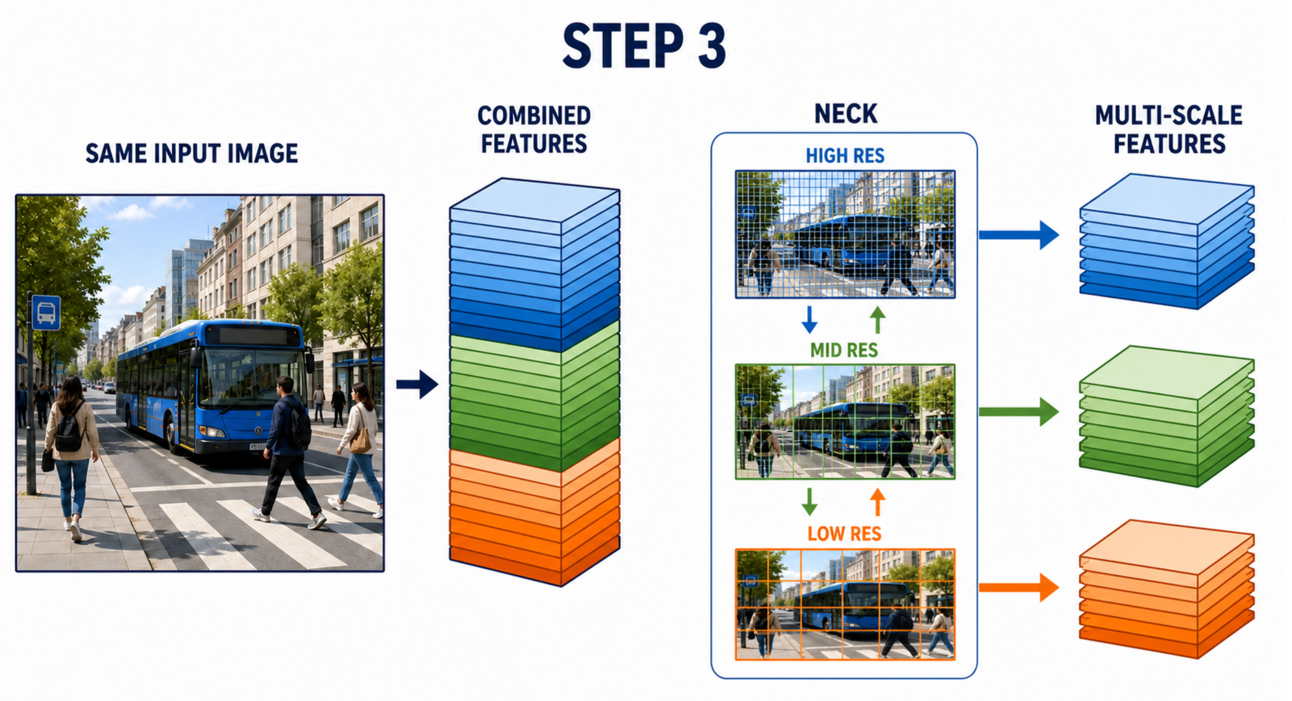

*STEP 1과 같은 버스 이미지를 세 번 따로 분석하는 것이 아니다. 한 번 추출한 특징을 서로 다른 공간 크기로 정리하고 결합하여, 같은 장면의 작은 객체와 큰 객체를 모두 찾을 준비를 한다.*

이 단계까지는 아직 `person`, `bus`라는 최종 클래스나 바운딩 박스를 출력하지 않는다.
Neck의 결과인 **Multi-scale Features**를 다음 Detection Head에 전달한다.


### 4단계: Detection Head가 객체 후보를 만든다

Detection Head는 Multi-scale Features의 여러 위치에 같은 학습된 합성곱 연산을 적용하여 후보를 동시에 계산한다.
각 위치에는 feature map 여러 채널의 값이 모여 있으며, 이를 **해당 위치를 설명하는 특징값 묶음**으로 볼 수 있다.

예를 들어 버스가 있는 위치에서는 다음 특징들이 함께 강하게 나타날 수 있다.

- `큰 직사각형 형태 + 반복되는 창문 + 바퀴 곡선 + 파란색 영역`

사람이 있는 위치에서는 다음과 같은 다른 조합이 나타날 수 있다.

- `머리의 둥근 경계 + 세로 방향 몸통 + 팔·다리의 경계 + 사람 크기의 영역`

Detection Head는 학습된 가중치를 이용해 이 특징값 묶음을 두 갈래로 계산한다.

1. **Class branch**: `person`, `bus`, `car` 등 클래스별 점수를 계산한다.
2. **Box branch**: 객체가 있을 것으로 예상되는 바운딩 박스의 위치와 크기를 계산한다.

```text
Multi-scale Feature의 위치별 특징값
                 ↓
          Detection Head
          ↙             ↘
  클래스별 점수       박스 좌표
  bus 0.94           x, y, w, h
```

어떤 후보에서 `bus=0.94`, `person=0.02`가 나오면 버스 후보로 해석한다.
다른 후보에서 `person=0.88`, `bus=0.03`이 나오면 사람 후보로 해석한다.

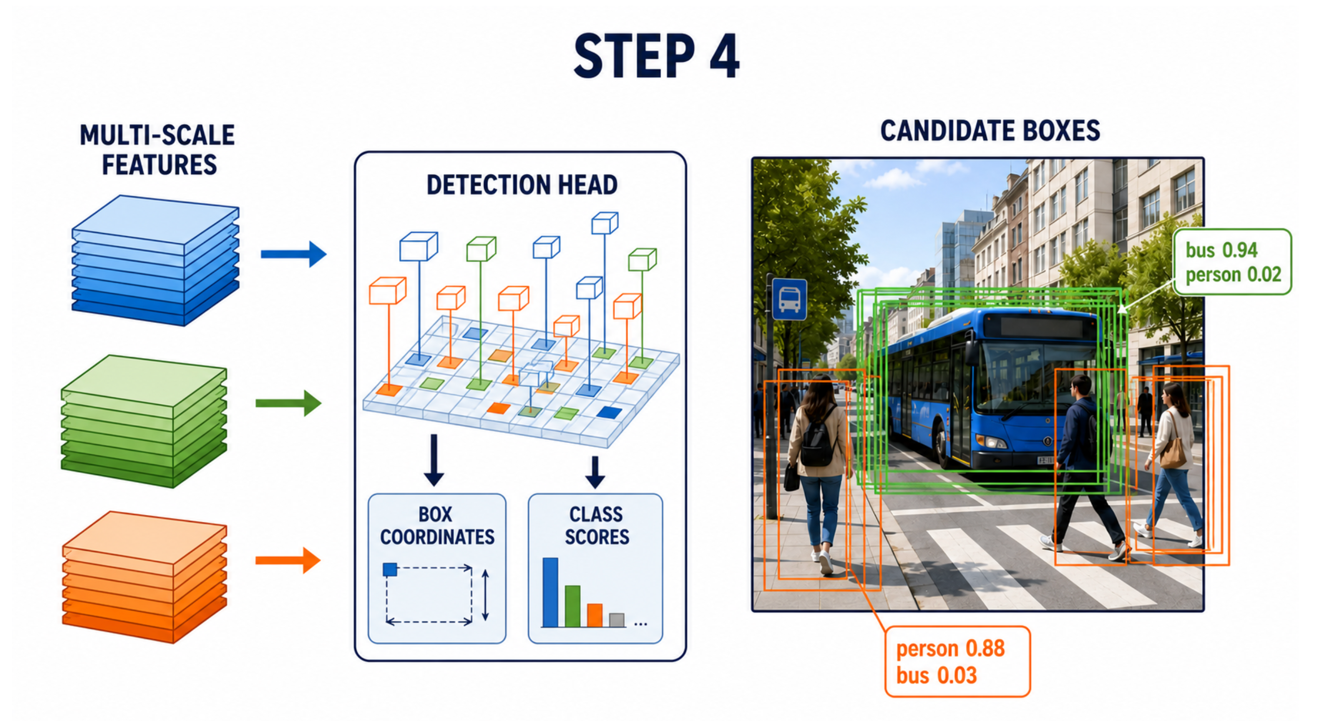

*같은 버스와 사람 주변에 박스가 여러 개 보이는 이유는 feature map의 가까운 여러 위치가 같은 객체에 반응하여 각각 후보를 만들기 때문이다. 이 결과는 아직 최종 탐지 결과가 아니다.*


### 5단계: confidence와 NMS로 후보를 정리한다

Detection Head가 만든 후보는 두 단계로 정리한다.

#### 5-1. confidence 필터링

confidence는 각 후보를 모델이 얼마나 확신하는지 나타내는 점수이다.
예를 들어 임계값이 `0.25`이면 다음과 같이 처리한다.

- 버스 후보 `0.94`, `0.76`은 남기고 `0.20`은 제거한다.
- 사람 후보 `0.88`, `0.72`는 남기고 `0.18`은 제거한다.

이 단계는 **후보 하나의 점수가 충분한지**만 확인한다. 박스끼리 겹치는지는 아직 비교하지 않는다.

#### 5-2. NMS로 중복 박스 제거

confidence 필터를 통과해도 같은 버스나 사람 주변에는 겹친 박스가 여러 개 남을 수 있다.
NMS는 같은 클래스의 후보 박스끼리 IoU를 계산하고, 같은 객체를 가리킬 만큼 많이 겹치면 confidence가 높은 박스만 남긴다.

- 버스 후보들의 IoU가 `0.78`이면 `0.94`를 남기고 중복 후보 `0.76`을 제거한다.
- 한 사람 주변 후보들의 IoU가 `0.81`이면 `0.88`을 남기고 중복 후보 `0.72`를 제거한다.

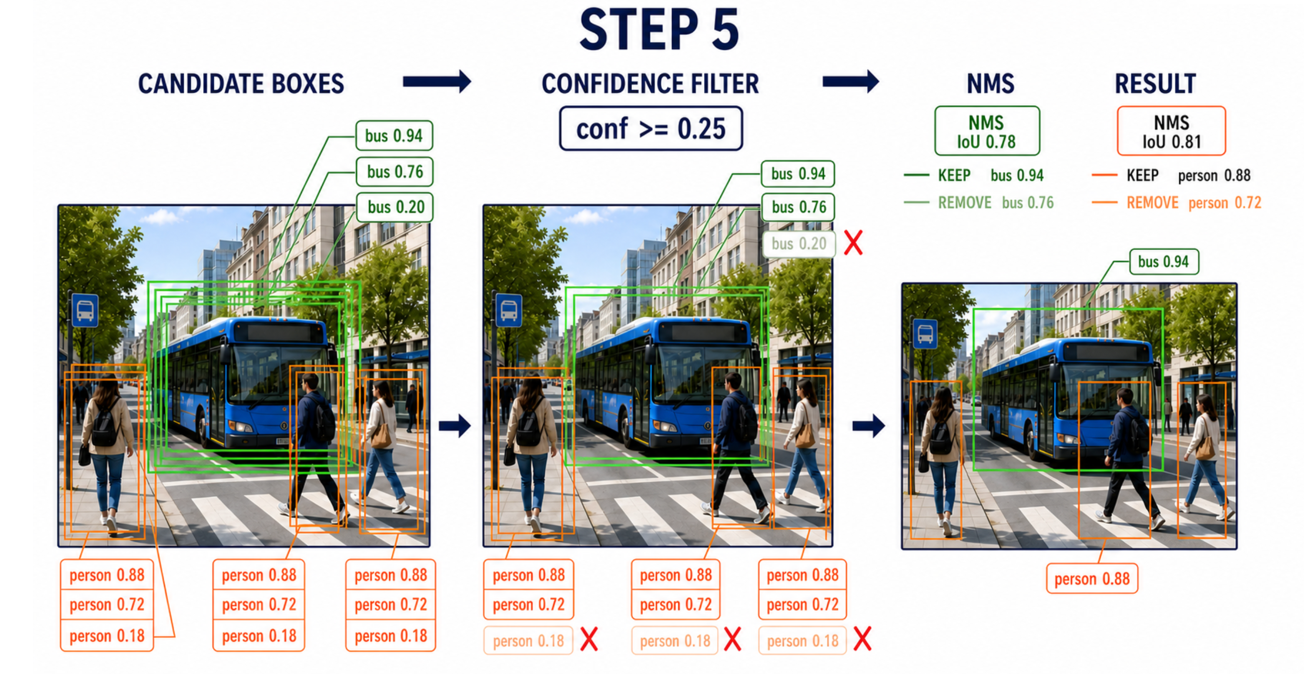

*NMS는 같은 클래스라는 이유만으로 박스를 하나만 남기지 않는다. 서로 떨어져 있는 세 사람은 각각 다른 객체이므로 최종 결과에서도 사람 박스가 각각 남고, 각 사람 주변의 겹친 중복 박스만 제거된다.*

### STEP 2부터 STEP 5까지 연결

```text
[Backbone]
같은 이미지에서 선·질감·부분 패턴 추출
        ↓
[Neck]
서로 다른 크기의 feature map 결합
        ↓
[Detection Head]
위치별 특징 조합으로 클래스 점수와 후보 박스 예측
        ↓
[Post-processing]
낮은 confidence 제거 → NMS로 중복 제거
        ↓
[최종 결과]
클래스 + confidence + 바운딩 박스
```

### 학습할 때와 사용할 때

- **학습 단계**: 클래스와 정답 박스가 표시된 이미지를 사용한다. 예측한 클래스·박스와 정답의 차이를 loss로 계산하고, 역전파와 optimizer가 Backbone, Neck, Detection Head의 가중치를 수정한다.
- **추론 단계**: 학습된 가중치를 이용해 처음 보는 이미지의 feature map을 만들고, 클래스 점수와 박스를 예측한 뒤 confidence 필터링과 NMS로 정리한다.

핵심은 **feature map 하나가 버스나 사람을 직접 의미하는 것이 아니라, 여러 위치·채널·크기의 특징값 조합을 학습된 Detection Head가 해석하여 객체를 구분한다는 것**이다.


### 실행 환경 준비

바운딩 박스, IoU, NMS 실습에는 PyTorch와 TorchVision을 사용하고, 실제 YOLO 추론에는 `ultralytics`를 사용한다.
아래 설치 셀을 실행하면 `ultralytics`가 현재 노트북 커널에 설치된다.

```bash
pip install ultralytics
```

In [ ]:
# %pip install ultralytics


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from fsspec.config import conf
from matplotlib.patches import Rectangle
from PIL import Image
from torch.ao.nn.quantized.functional import threshold
from torchvision.ops import nms

DATA_DIR = Path("data")
MODEL_DIR = Path("models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    YOLO_DEVICE = 0
elif torch.backends.mps.is_available():
    YOLO_DEVICE = "mps"
else:
    YOLO_DEVICE = "cpu"

print("실행 장치:", YOLO_DEVICE)
print("데이터 폴더:", DATA_DIR.resolve())
print("모델 폴더:", MODEL_DIR.resolve())


### 객체 탐지용 예시 이미지 확인

`data/yolo_bus.jpg`는 버스와 여러 사람이 함께 있어 한 이미지에서 여러 객체를 찾는 과정을 확인하기 좋다.
이 이미지는 [Ultralytics 공식 예시 이미지](https://ultralytics.com/images/bus.jpg)를 로컬로 다운로드한 것이다.


In [ ]:
image_path = DATA_DIR / "yolo_bus.jpg"

if not image_path.exists():
    raise FileNotFoundError(f"예시 이미지가 없습니다: {image_path.resolve()}")

sample_image = Image.open(image_path).convert("RGB")
image_array = np.asarray(sample_image)
image_width, image_height = sample_image.size

print("PIL 크기 (W, H):", sample_image.size)
print("NumPy shape (H, W, C):", image_array.shape)

plt.figure(figsize=(6, 7))
plt.imshow(sample_image)
plt.title("YOLO Input Image")
plt.axis("off")
plt.show()


## 2. 바운딩 박스와 좌표

바운딩 박스(Bounding Box)는 객체의 **위치와 범위**를 나타내는 직사각형이다.
이미지 좌표의 원점은 왼쪽 위이며, `x`는 오른쪽으로, `y`는 아래쪽으로 증가한다.

YOLO는 객체의 클래스와 박스 좌표를 함께 예측한다.

- 클래스 예측: `person`, `bus` 중 무엇인지 고르는 **분류 문제**
- 박스 예측: 객체의 위치와 크기를 연속적인 숫자로 맞히는 **회귀 문제**

주로 사용하는 좌표 표현은 다음과 같다.

- **`xyxy`**: 왼쪽 위 `(x1, y1)`와 오른쪽 아래 `(x2, y2)`의 픽셀 좌표
- **`xywh`**: 중심 `(x_center, y_center)`와 박스의 너비·높이
- **정규화 `xywh`**: `x`와 너비는 이미지 너비 `W`로, `y`와 높이는 이미지 높이 `H`로 나눈 0~1 값

추론 결과는 주로 `xyxy`로 읽고, YOLO 학습 라벨은 정규화 `xywh`를 사용한다.
학습 과정에서는 예측 박스와 정답 박스의 차이를 loss에 반영하여 박스 예측 가중치를 수정한다.

### 바운딩 박스 시각화

아래 좌표는 `xyxy`의 의미를 확인하기 위해 직접 지정한 예시이다.
실제 추론에서는 학습된 YOLO가 객체마다 이 좌표를 예측한다.

In [ ]:
example_box = [20, 230, 790, 760]
x1, y1, x2, y2 = example_box

box_width = x2 - x1
box_height = y2 - y1

fig, axis = plt.subplots(figsize=(6, 7))
axis.imshow(sample_image)

axis.add_patch(Rectangle(
    (x1, y1),
    box_width,
    box_height,
    fill=False,
    edgecolor="lime",
    linewidth=3,
))
axis.text(x1, y1 - 10, "bus", color="lime", fontsize=12)
axis.set_title("Bounding Box Example")
axis.axis("off")
plt.show()

print("이미지 크기 (W, H):", sample_image.size)
print("xyxy 좌표:", example_box)
print("박스 크기 (width, height):", (box_width, box_height))


## 3. IoU와 NMS

YOLO는 같은 객체 주변에 후보 박스를 여러 개 만들 수 있다.
**IoU**는 박스 두 개의 겹침 정도를 계산하고, **NMS**는 이를 이용해 중복 후보를 제거한다.

### IoU: 두 박스의 겹침 정도

`IoU = 두 박스의 교집합 넓이 ÷ 두 박스의 합집합 넓이`

- `0`: 전혀 겹치지 않음
- `1`: 위치와 크기가 완전히 같음

IoU는 비교 대상에 따라 용도가 달라진다.

1. **평가**: 예측 박스와 정답 박스를 비교한다.
2. **NMS**: 예측 후보 박스끼리 비교한다.

confidence는 **후보 하나의 확신 점수**이고, IoU는 **박스 두 개의 겹침 값**이다.
평가용 IoU 기준과 NMS의 IoU 임계값은 역할이 다른 별도의 설정이다.

### IoU 계산과 그림 확인

기준 박스 A와 겹치는 박스 B의 넓이가 각각 `10,000`이고, 겹친 부분이 `4,900`이라고 가정한다.

1. 교집합 넓이: `4,900`
2. 합집합 넓이: `10,000 + 10,000 - 4,900 = 15,100`
3. IoU: `4,900 ÷ 15,100 ≈ 0.325`

여기서 `0.325`는 정확도 32.5%라는 뜻이 아니라 **두 박스의 합집합 중 약 32.5%가 겹친다**는 뜻이다.
아래에서는 일부 겹침, 겹치지 않음, 완전히 같음 세 경우를 숫자와 그림으로 비교한다.

In [ ]:
def calculate_iou(box_a, box_b):
    '''두 [x1, y1, x2, y2] 박스의 IoU와 계산 중간값을 반환한다.'''

    intersection_x1 = max(box_a[0], box_b[0])
    intersection_y1 = max(box_a[1], box_b[1])

    intersection_x2 = min(box_a[2], box_b[2])
    intersection_y2 = min(box_a[3], box_b[3])

    intersection_width = max(0, intersection_x2 - intersection_x1)
    intersection_height = max(0, intersection_y2 - intersection_y1)
    intersection_area = intersection_width * intersection_height

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union_area = area_a + area_b - intersection_area
    iou = intersection_area / union_area if union_area > 0 else 0.0

    return iou, intersection_area, union_area

reference_box = [20, 20, 120, 120]
overlap_box = [50, 50, 150, 150]
separate_box = [160, 20, 230, 100]

comparison_cases = [
    (overlap_box, "Partial overlap"),
    (separate_box, "No overlap"),
    (reference_box, "Same box"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, (comparison_box, title) in zip(axes, comparison_cases):
    iou, intersection_area, union_area = calculate_iou(
        reference_box,
        comparison_box,
    )

    for box, color, label in [
        (reference_box, "royalblue", "A"),
        (comparison_box, "darkorange", "B"),
    ]:
        x1, y1, x2, y2 = box
        axis.add_patch(Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            facecolor=color,
            edgecolor=color,
            alpha=0.30,
            linewidth=2,
            label=label,
        ))

    axis.set_xlim(0, 250)
    axis.set_ylim(180, 0)
    axis.set_aspect("equal")
    axis.set_title(f"{title}\nIoU={iou:.3f}")
    axis.legend()

    print(
        f"{title}: 교집합={intersection_area}, "
        f"합집합={union_area}, IoU={iou:.3f}"
    )

plt.tight_layout()
plt.show()


### NMS: 같은 객체의 중복 박스 제거

NMS(Non-Maximum Suppression)는 같은 객체를 가리키는 후보 중 confidence(신뢰도)가 가장 높은 박스를 남기고, 그 박스와 IoU가 임계값보다 큰 중복 후보를 제거하는 후처리이다.

예를 들어 같은 사람의 후보가 `0.95`, `0.82`이고 두 박스의 IoU가 `0.81`이라면, NMS 임계값 `0.50`을 넘으므로 `0.95` 박스만 남긴다. 다른 위치의 사람 박스는 거의 겹치지 않으므로 별도 객체로 남는다.

- NMS IoU 임계값이 낮으면 중복 박스를 더 적극적으로 제거한다.
- NMS IoU 임계값이 높으면 겹친 박스가 더 많이 남을 수 있다.

`torchvision.ops.nms()`는 클래스 번호를 입력받지 않으므로 아래 예제는 **모든 후보가 같은 클래스라고 가정**한다.
실제 Ultralytics YOLO는 기본적으로 클래스별로 중복을 처리하므로 사람 박스가 버스 박스를 제거하지 않는다.

In [ ]:
# 세 박스는 모두 person 클래스라고 가정한다.
# 0번과 1번은 같은 사람의 중복 후보이고, 2번은 다른 위치의 사람이다.
candidate_boxes = torch.tensor([
    [20, 20, 120, 120],   # 후보 0: 첫 번째 사람
    [28, 28, 118, 118],   # 후보 1: 후보 0과 많이 겹치는 중복 박스
    [150, 30, 235, 130],  # 후보 2: 다른 위치의 사람
], dtype=torch.float32)

# 동일한 인덱스의 값은 각 후보 박스의 confidence이다.
candidate_scores = torch.tensor([0.95, 0.82, 0.90])

iou_0_1, _, _ = calculate_iou(
    candidate_boxes[0].tolist(),
    candidate_boxes[1].tolist(),
)
print(f"후보 0과 1의 IoU: {iou_0_1:.3f}")

# torchvision.ops.nms()는 박스와 점수만 사용하므로 같은 클래스끼리 적용한다.
kept_indices = nms(
    candidate_boxes,
    candidate_scores,
    iou_threshold=0.5,
)

print("전체 후보 인덱스:", [0, 1, 2])
print("NMS 통과 인덱스:", kept_indices.tolist())
print("남은 confidence:", candidate_scores[kept_indices].tolist())


# NMS 전 후보 세 개와 NMS 후 선택된 후보를 비교한다.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cases = [
    (list(range(len(candidate_boxes))), "Before NMS"),
    (kept_indices.tolist(), "After NMS"),
]
colors = ["royalblue", "darkorange", "seagreen"]

for axis, (indices, title) in zip(axes, plot_cases):
    for index in indices:
        x1, y1, x2, y2 = candidate_boxes[index].tolist()
        score = candidate_scores[index].item()
        axis.add_patch(Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor=colors[index],
            linewidth=3,
        ))
        axis.text(x1, y1 - 4, f"{index}: {score:.2f}", color=colors[index])

    axis.set_xlim(0, 250)
    axis.set_ylim(150, 0)
    axis.set_aspect("equal")
    axis.set_title(title)

plt.tight_layout()
plt.show()


## 4. Ultralytics YOLO11 사용

Ultralytics는 PyTorch 기반 YOLO 모델을 쉽게 학습하고 추론할 수 있는 API를 제공한다.
빠른 수업 실습과 전통적인 NMS 설명에 적합한 `yolo11n.pt`를 사용한다.

`n`은 nano 모델을 의미한다. 모델이 작아 비교적 빠르지만 큰 모델보다 정확도가 낮을 수 있다.

### yolo11n이 구분할 수 있는 객체(클래스) 80종

기본 `yolo11n.pt` 모델은 COCO 데이터셋의 80개 객체 클래스를 인식한다.
> COCO(Common Objects in Context): 컴퓨터 비전 모델을 학습하고 평가하기 위해 만든 대규모 이미지 데이터셋

* **사람:** person(사람)
* **교통수단·도로 시설:** bicycle(자전거), car(자동차), motorcycle(오토바이), airplane(비행기), bus(버스), train(기차), truck(트럭), boat(보트), traffic light(신호등), fire hydrant(소화전), stop sign(정지 표지판), parking meter(주차요금 계산기), bench(벤치)
* **동물:** bird(새), cat(고양이), dog(개), horse(말), sheep(양), cow(소), elephant(코끼리), bear(곰), zebra(얼룩말), giraffe(기린)
* **패션·휴대 물품:** backpack(배낭), umbrella(우산), handbag(핸드백), tie(넥타이), suitcase(여행가방)
* **스포츠 용품:** frisbee(프리스비), skis(스키), snowboard(스노보드), sports ball(스포츠 공), kite(연), baseball bat(야구 방망이), baseball glove(야구 글러브), skateboard(스케이트보드), surfboard(서핑보드), tennis racket(테니스 라켓)
* **식기류:** bottle(병), wine glass(와인잔), cup(컵), fork(포크), knife(칼), spoon(숟가락), bowl(그릇)
* **음식:** banana(바나나), apple(사과), sandwich(샌드위치), orange(오렌지), broccoli(브로콜리), carrot(당근), hot dog(핫도그), pizza(피자), donut(도넛), cake(케이크)
* **가구·생활용품:** chair(의자), couch(소파), potted plant(화분), bed(침대), dining table(식탁), toilet(변기), book(책), clock(시계), vase(꽃병), scissors(가위), teddy bear(곰인형), hair drier(헤어드라이어), toothbrush(칫솔)
* **전자기기·가전제품:** tv(텔레비전), laptop(노트북), mouse(마우스), remote(리모컨), keyboard(키보드), cell phone(휴대전화), microwave(전자레인지), oven(오븐), toaster(토스터), sink(싱크대), refrigerator(냉장고)




참고 문서:

- [Ultralytics 객체 탐지](https://docs.ultralytics.com/tasks/detect/)
- [Predict 모드와 Results 객체](https://docs.ultralytics.com/modes/predict/)


### 사전학습 모델 다운로드와 로컬 폴더 배치

YOLO11 Nano의 사전학습 가중치 파일은 `yolo11n.pt`이다.
아래 셀은 노트북과 같은 위치의 `models/yolo11n.pt`를 최종 모델 경로로 사용한다.

1. `models/yolo11n.pt`가 이미 있으면 다시 다운로드하지 않고 바로 불러온다.
2. 파일이 없으면 Ultralytics가 `yolo11n.pt`를 다운로드한다.
3. 다운로드된 파일을 `models/yolo11n.pt`로 이동한다.
4. 이후 모든 추론은 `models/yolo11n.pt`를 사용한다.

In [ ]:
from shutil import move

from ultralytics import YOLO

local_model_path = MODEL_DIR / "yolo11n.pt"

if local_model_path.exists():

    print("기존 모델 파일 사용:", local_model_path.resolve())
else:

    print("yolo11n.pt 다운로드를 시작합니다.")
    downloaded_model = YOLO("yolo11n.pt")

    downloaded_path_value = getattr(downloaded_model, "ckpt_path", None)
    downloaded_path = (
        Path(downloaded_path_value)
        if downloaded_path_value
        else Path("yolo11n.pt")
    )

    if not downloaded_path.exists():
        raise FileNotFoundError(
            f"다운로드된 yolo11n.pt를 찾을 수 없습니다: {downloaded_path.resolve()}"
        )

    move(str(downloaded_path), str(local_model_path))
    print("모델 파일 이동 완료:", local_model_path.resolve())

yolo_model = YOLO(str(local_model_path))
print("YOLO11 모델 준비 완료:", local_model_path.resolve())


### 이미지 한 장 추론

`predict()`는 이미지 전처리, 순전파, confidence 필터링, NMS를 수행하고 `Results` 객체 목록을 반환한다.

- `conf=0.25`: confidence가 0.25 미만인 후보를 제거한다.
- `iou=0.70`: NMS에서 중복 후보를 판단하는 IoU 임계값이다.
- `imgsz=640`: 원본 비율을 유지해 크기를 조정하고 필요한 여백을 더할 때 사용하는 기준 크기이다.

`conf`는 후보 하나를 거르는 기준이고, `iou`는 후보 두 개의 중복을 판단하는 기준이다.
여기의 `iou`는 mAP 평가용 IoU 기준과 별개이다.

In [ ]:
# predict() 예측 순서
# -> 전처리 -> 순전파 -> CNN 결과(바운딩 박스 n개, confidence)
# -> confidence 필터링(1차 바운딩 박스 제거)
# -> NMS(IoU가 0~1 사이의 겹치는 박스 중 confidence가 제일 높은 박스만 남김)

# 예측 결과로 이미지에서 탐지된 객체별 box 반환됨
yolo_results = yolo_model.predict(
    source=sample_image,
    conf=0.25, # confidence가 0.25 미만이면 바운딩 박스 제거
    iou=0.70, # 겹치는 바운딩 박스의 iou 수치가 0.7 이상이면 중복 객체로 판단
              # 0.7 미만이면 서로 박스 일부가 겹치는 다른 객체로 판단
    imgsz=640, # 모델에 입력할 이미지 사이즈(모델 입력 전처리 단계)
    device=YOLO_DEVICE,
    verbose=True, # 모델 상세 로그 출력 off
)

# 이미지 한 장을 전달했으므로 0번 인덱스 요소만 꺼내옴
result = yolo_results[0]

print("원본 이미지 shape: ", result.orig_shape)
print("설정된 입력 기준 크기:", yolo_model.predictor.imgsz)
print("탐지된 객체 수:", len(result.boxes))
print("단계별 처리 시간(ms):", result.speed)


### 바운딩 박스가 표시된 결과 확인

`result.plot()`은 최종 박스, 클래스 이름, confidence를 원본 이미지 위에 그린다.
모델이 사람과 버스를 각각 어떤 박스로 찾았는지 확인한다.


In [ ]:
result = yolo_results[0]

# result.plot() : box가 그려진 BGR 배열, 클래스, confidence가 반환됨
annotated_rgb = result.plot()[:, :, ::-1] # BGR -> RGB로 뒤집기

plt.figure(figsize=(7, 8))
plt.imshow(annotated_rgb)
plt.title("YOLO11 Detection Result")
plt.axis("off")
plt.show()


### 탐지 결과의 숫자 정보 확인

시각화 결과를 프로그램에서 사용하려면 `result.boxes`에서 값을 읽는다.

- `boxes.xyxy`: 각 박스의 픽셀 좌표 `(탐지 수, 4)`
- `boxes.conf`: 각 박스의 confidence `(탐지 수,)`
- `boxes.cls`: 각 박스의 클래스 번호 `(탐지 수,)`

동일한 인덱스의 `xyxy`, `conf`, `cls`가 객체 하나의 정보를 구성한다.


In [ ]:
result = yolo_results[0]
boxes = result.boxes

xyxy_values = boxes.xyxy.detach().cpu()
confidence_values = boxes.conf.detach().cpu()
class_values = boxes.cls.detach().cpu().to(torch.int64)

for index in range(min(10, len(boxes))):
    class_id = int(class_values[index].item())
    class_name = result.names[class_id]
    confidence = float(confidence_values[index].item())
    coordinates = [round(value, 1) for value in xyxy_values[index].tolist()]

    print(
        f"{index}: class={class_name}, "
        f"confidence={confidence:.3f}, xyxy={coordinates}"
    )


## 5. confidence 임계값 조절

confidence 임계값은 확신이 낮은 후보를 제거하는 기준이다.

- 낮추면 더 많은 객체를 찾지만 오탐이 늘 수 있다.
- 높이면 확실한 결과만 남지만 실제 객체를 놓칠 수 있다.

아래에서는 차이를 쉽게 확인하도록 `0.25`와 `0.90`을 비교한다.
정확한 박스 수와 점수는 모델 버전과 실행 환경에 따라 달라질 수 있으며, 임계값은 서비스 목적에 맞게 정한다.

In [ ]:
thresholds = [0.25, 0.90]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for axis, threshold in zip(axes, thresholds):
    threshold_results = yolo_model.predict(
        source=sample_image,
        conf=threshold,
        iou=0.70,
        imgsz=640,
        device=YOLO_DEVICE,
        verbose=False,
    )

    axis.imshow(threshold_results[0].plot()[:,:,::-1])
    axis.set_title(f'conf={threshold}, boxes={len(threshold_results[0].boxes)}')
    axis.axis('off')

plt.tight_layout()
plt.show()


## 6. 여러 객체가 있는 이미지로 YOLO11 탐지 실습

앞에서는 버스 이미지를 이용해 YOLO의 처리 과정과 confidence 임계값을 나누어 확인했다.
이번에는 사람과 주방용품이 함께 있는 `data/coco_kitchen.jpg`를 `models/yolo11n.pt`에 입력해 **여러 객체를 한 번에 탐지하는 과정**을 실행한다.

1. 이미지를 불러온다.
2. `predict()`로 여러 객체를 탐지한다.
3. 바운딩 박스가 표시된 결과를 확인한다.
4. 클래스 이름, confidence, `xyxy` 좌표와 클래스별 탐지 수를 읽는다.

이 과정은 이미 학습된 가중치로 결과만 계산하는 **추론(inference)** 이며 모델의 가중치는 바뀌지 않는다.
탐지 결과는 정답이 아니므로 실제 이미지와 비교하면서 미탐과 오탐이 있는지도 함께 확인한다.

이미지 출처: [COCO 2017 Validation 이미지 000000397133](http://images.cocodataset.org/val2017/000000397133.jpg)


In [ ]:
# practice_image_path = DATA_DIR / "coco_kitchen.jpg"
practice_image_path = DATA_DIR / "restaurant.jpg"
if not practice_image_path.exists():
    raise FileNotFoundError(f"실습 이미지를 찾을 수 없습니다: {practice_image_path.resolve()}")

practice_image = Image.open(practice_image_path).convert("RGB")

practice_result = yolo_model.predict(
    source=practice_image,
    conf=0.25,
    iou=0.80,
    imgsz=640,
    device=YOLO_DEVICE,
    verbose=False,
)[0]

practice_annotated_rgb = practice_result.plot()[:, :, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(practice_image)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(practice_annotated_rgb)
axes[1].set_title("YOLO11 Detection")
axes[1].axis("off")

plt.tight_layout()
plt.show()

class_counts = {}
print("탐지된 객체 수:", len(practice_result.boxes))

for index, box in enumerate(practice_result.boxes):
    class_id = int(box.cls.item())
    class_name = practice_result.names[class_id]
    confidence = float(box.conf.item())
    coordinates = [round(value, 1) for value in box.xyxy[0].detach().cpu().tolist()]

    class_counts[class_name] = class_counts.get(class_name, 0) + 1
    print(
        f"{index}: class={class_name}, "
        f"confidence={confidence:.3f}, xyxy={coordinates}"
    )

print("클래스별 탐지 수:", class_counts)


## 7. 커스텀 객체 탐지 학습

직접 정의한 객체를 찾으려면 이미지마다 클래스와 바운딩 박스를 라벨링해야 한다.
학습용 `train`과 검증용 `val` 데이터를 분리하며, 이미지와 라벨 파일의 이름을 같게 만든다.

```text
data/my_detection/
├── data.yaml
├── images/train, images/val
└── labels/train, labels/val
```

예를 들어 `images/train/a.jpg`의 라벨은 `labels/train/a.txt`이다.
객체 한 개를 한 줄로 기록하며, 한 이미지에 객체가 세 개면 세 줄을 작성한다.

```text
class_id x_center y_center width height
```

네 좌표는 이미지 너비와 높이로 나눈 0~1 범위의 정규화 값이다.


### `data.yaml`과 학습 코드

`data.yaml`은 데이터셋 기준 경로, 학습·검증 이미지 위치, 클래스 이름을 정의한다.
아래 `path: data/my_detection`은 노트북 폴더에서 실행하는 것을 기준으로 하며 실제 폴더가 준비되어 있어야 한다.
사전학습 YOLO11에서 시작하면 기존 시각 특징을 재사용하는 전이학습이 된다.


In [ ]:
data_yaml_example = """path: data/my_detection
train: images/train
val: images/val

names:
  0: helmet
  1: person
"""

print("data.yaml 예시")
print(data_yaml_example)

training_code = """
model = YOLO("models/yolo11n.pt")
model.train(
    data="data/my_detection/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
)
"""

print("학습 코드 예시")
print(training_code)


## 8. 객체 탐지 평가 지표

객체 탐지는 클래스와 위치가 모두 맞아야 한다.
일반적으로 **클래스가 맞고 예측 박스와 정답 박스의 IoU가 평가 기준 이상일 때 TP**로 판단한다.

- **Precision**: 모델이 찾았다고 한 객체 중 실제로 맞은 비율이다. 오탐이 많으면 낮아진다.
- **Recall**: 실제 객체 중 모델이 찾아낸 비율이다. 미탐이 많으면 낮아진다.
- **AP**: confidence 임계값을 바꾸며 얻은 Precision-Recall 곡선 아래 면적이다.
- **mAP50**: IoU 0.50에서 계산한 클래스별 AP의 평균이다.
- **mAP50-95**: IoU 0.50~0.95 기준의 mAP를 평균해 박스 위치를 더 엄격하게 평가한다.

객체 누락이 위험하면 Recall을, 오탐 비용이 크면 Precision을 특히 확인하고 mAP도 함께 본다.

In [ ]:
true_positive = 8
false_positive = 2
false_negative = 4

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")


## 9. 핵심 요약

1. 객체 탐지는 이미지에서 **무엇이 어디에 있는지**를 찾는다.
2. 바운딩 박스는 객체의 위치와 범위를 표시하는 사각형이다.
3. confidence는 모델의 확신 정도이고, IoU는 두 박스의 겹침 정도이다.
4. NMS는 같은 객체를 가리키는 중복 박스 중 confidence가 높은 박스를 남긴다.
5. YOLO의 `Results.boxes`에서 `xyxy`, `conf`, `cls`를 읽을 수 있다.
6. confidence 임계값을 높이면 박스 수가 줄지만 미탐이 증가할 수 있다.
7. 커스텀 학습에는 이미지, 바운딩 박스 라벨, `data.yaml`이 필요하다.
8. 성능은 Precision, Recall, mAP50, mAP50-95를 함께 해석한다.
